In [ ]:
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import random_unitary, Statevector
from qiskit.circuit.random import random_circuit
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer.noise import NoiseModel, ReadoutError

In [ ]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)


# The problem

> ### Random Circuit Sampling
> **Input:**  
> * A random quantum circuit C.
>
> **Output:**  
> * The output of the circuit.

# Importance of the problem

Random Circuit Sampling is an important problem because it provides a simple way to test whether a quantum device can generate probability distributions that are hard to reproduce classically. The goal is simply to sample from the output distribution of a randomly generated quantum circuit, but as the number of qubits and gates increases, the resulting distribution becomes extremely complex, making classical simulation increasingly difficult. For this reason, Random Circuit Sampling has been widely used as a benchmark for demonstrating quantum computational advantage, often referred to as quantum supremacy: the point at which a quantum processor performs a well-defined task that is infeasible for the best available classical computers.

# Cross-entropy benchmark fidelity

Intead of a Random Circuit, we can think of a random unitary $U$ thats is applied to the $|0\rangle ^{\otimes n}$ state in order to obtain the state $|\psi_U \rangle = U |0\rangle$, that will induce a probability distribution $p_U(x)$. With that, we can either sample  strings $x_s$ by measuring strings from $|\psi_U$ or we can sample strings $x_r$ uniformly at random and hope that the distribution is close to the Random Circuit one. However, it can be proven that they are quite different, indeed:

$$
a_s=\frac{2}{2^n+1}
$$

while:

$$
a_r\approx \frac{1}{2^n}
$$

As $n$ grows, we can see that:

$$
a_s\approx 2 a_r
$$


In order to compare the random and actual distributions we can either plot them to see the difference in shape and use the cross-entropy benchmark fidelity. It is defined by:

$$
F_{XEB}\left(x_1,...,x_k  \right)= \left ( \frac{2^n}{k}\sum^k_{j=1}p_U(x_j) \right) -1
$$

Given the expressions for $a_r$ and $a_s$, we can easily see that if you sample from $p_U(x)$, you will get $F_{XEB}$ values close to 1, while if you sample uniformly at random, you will get values close to 0. Moreover, it can be proven that obtaining a value of $F_{XEB}$ bigger than 0 is computationally hard for classical computers, so we can use this metric to quantitatively measure the performance of quantum computers.

# Implementation

First, let's sample from random unitaries $U$ and compare their distributions and values of $F_{XEB}$.

In [7]:
def F_xeb(p: list, n: int) -> float:
    """
    Compute the cross-entropy benchmarking fidelity F_xeb for a given list of probabilities p and number of qubits n.
    """
    return round(2**n * np.mean(p) - 1, 3)

In [8]:
# Define parameters
n = 10
n_unitaries = 200
n_samples = 20

Random sampling fidelity: -0.026


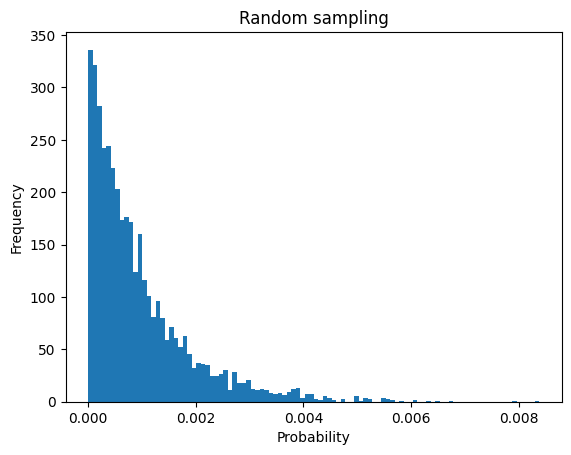

In [ ]:
# Sampling uniformly at random
p_r = []

for i in range(n_unitaries):
    # Generate a random unitary matrix of size 2^n
    U = random_unitary(2**n, seed = SEED + i).to_matrix() 
    # Get the probabilities
    probs = np.abs(U[:, 0])**2

    for _ in range(n_samples):
        # Sample a random index r from 0 to 2^n - 1
        r = np.random.randint(0, 2**n)
        # Append the probability of the sampled index to the list
        p_r.append(probs[r])

# Get the fidelity for random sampling
random_fid = F_xeb(p_r, n)
print(f"Random sampling fidelity: {random_fid}")

# Plot the histogram
plt.hist(p_r, bins = 100)
plt.title("Random sampling")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

Sampling with probabilities fidelity: 0.988


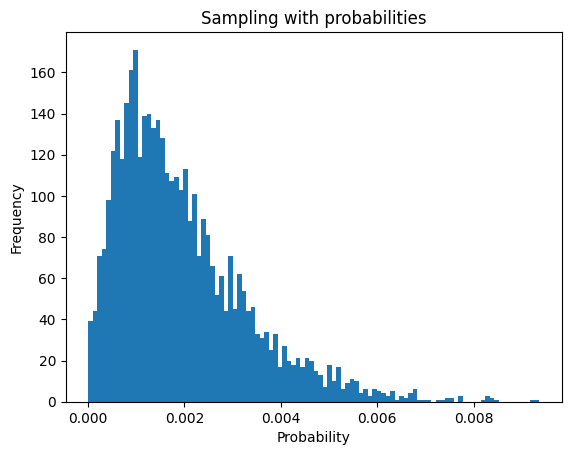

In [ ]:
# Sampling with probabilities
p_s = []

for i in range(n_unitaries):
    # Generate a random unitary matrix of size 2^n
    U = random_unitary(2**n, seed = SEED + i).to_matrix()
    # Get the probabilities
    probs = np.abs(U[:, 0])**2

    for _ in range(n_samples):
        # Sample an index r from 0 to 2^n - 1 with probabilities given by probs
        r = np.random.choice(2**n, p = probs)
        # Append the probability of the sampled index to the list
        p_s.append(probs[r])

# Get the fidelity for sampling with probabilities
sampling_fid = F_xeb(p_s, n)
print(f"Sampling with probabilities fidelity: {sampling_fid}")

# Plot the histogram
plt.hist(p_s, bins = 100)
plt.title("Sampling with probabilities")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

From the histogram is clear that the distributions are different: when sampling uniformly at random, most strings concentrate around the smallest probabilities; when sampling with the actual probabilities the string tend to have higher probabilities.

If we look at the values of the cross-entropy benchmark fidelity they are exactly as expected: when sampling uniformly at random it's very close to 0, while when sampling with the actual probabilities it's very close to 1.

Let's now use actual random circuits instead of random unitaries and use noise models to study the influence of the precision of the hardware in the value of $F_{XEB}$.

In [ ]:
# Define parameters
n = 10
n_circuits = 200
n_samples = 20
n_layers = 200
error_list = [0, 0.025, 0.05, 0.1]

In [55]:
# Fidelity for sampling with random circuits under different noise levels
fidelities = []

for p_error in error_list:
    # Define a noise model with a readout error
    noise_model = NoiseModel()
    readout_error = ReadoutError([[1-p_error, p_error],  # |0> is measured incorrectly as |1> with probability p_error
                                [p_error, 1-p_error]]) # |1> is measured incorrectly as |0> with probability p_error
    noise_model.add_all_qubit_readout_error(readout_error)
    noisy_simulator = AerSimulator(noise_model=noise_model, seed_simulator=SEED)

    # Sampling with random circuits
    p_c = []

    for i in range(n_circuits):
        # Generate a random circuit with n qubits and n_layers depth (max_operands = 2 to ensure max 2-qubit gates)
        qc = random_circuit(
            num_qubits = n,
            depth = n_layers,
            seed = 1234 + i,
            max_operands = 2, 
            measure = True
        )
        # Transpile and run
        qc_t = transpile(qc, backend=noisy_simulator, optimization_level=0)
        job = noisy_simulator.run(qc_t, shots=n_samples, seed_simulator=SEED, memory=True)
        result = job.result()

        # Get the bitstrings and convert them to integer indices
        bitstrings = result.get_memory(qc_t)
        meas_idx = [int(b, 2) for b in bitstrings]

        # Remove final measurements to compute the statevector
        qc.remove_final_measurements()
        sv = Statevector(qc)
        for idx in meas_idx:
            # Append the probability of the measured state
            p_c.append(abs(sv[idx])**2)

    # Get the fidelity for sampling with random circuits
    circuit_fid = F_xeb(p_c, n)
    fidelities.append(circuit_fid)
    print(f"Noise: {p_error}, Fidelity: {circuit_fid}")

Noise: 0, Fidelity: 1.265
Noise: 0.025, Fidelity: 0.944
Noise: 0.05, Fidelity: 0.762
Noise: 0.1, Fidelity: 0.597


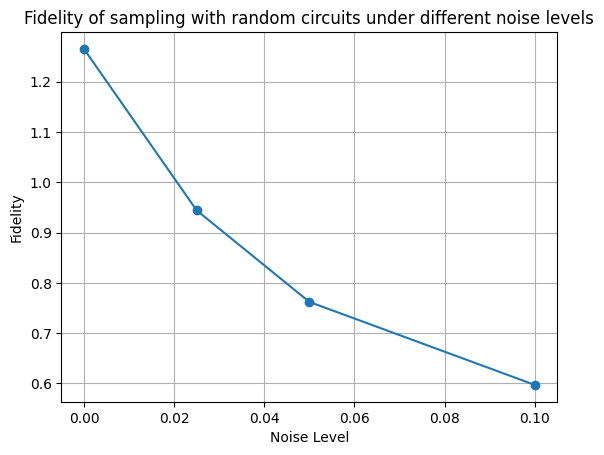

In [57]:
# Plot the fidelities as a function of the noise level
plt.plot(error_list, fidelities, marker='o')
plt.title("Fidelity of sampling with random circuits under different noise levels")
plt.xlabel("Noise Level")
plt.ylabel("Fidelity")
plt.grid()
plt.show()

As expected, the XEB fidelity decreases as the readout error probability increases. When the noise level is low, the measured bitstrings are still close to the ideal output distribution of the random circuits, so the fidelity remains relatively high. However, as measurement errors become more frequent, the sampled bitstrings deviate more from the ideal probabilities, causing the XEB fidelity to drop. This illustrates how Random Circuit Sampling is sensitive to noise and why XEB fidelity is useful for quantifying how close a noisy quantum device is to the ideal quantum sampling distribution.